In [1]:
import rasterio
import rasterio.plot
from rasterio.transform import from_origin

import json
import numpy as np
import pandas as pd
import geopandas as gpd
from geopandas import GeoDataFrame
import matplotlib.pyplot as plt

from scipy.ndimage import binary_dilation
from pyproj import Geod
from shapely.geometry import Point, LineString

In [2]:
topology = "data/grid/IEEE_30_bus_system.geojson"
intensity = "outputs/FARSITE/34/weather_N/runs/branch_1/point_1/_Intensity.asc"
arrival = "outputs/FARSITE/34/weather_N/runs/branch_1/point_1/_ArrivalTime.asc"

In [3]:
# Load GeoJSON file
gdf = gpd.read_file(topology)

# Read ASCII file and convert data to numpy array
with open(intensity) as f:
    ascii_data = f.readlines()

In [57]:
# Extract header information
ncols = int(ascii_data[0].split()[1])
nrows = int(ascii_data[1].split()[1])
xllcorner = float(ascii_data[2].split()[1])
yllcorner = float(ascii_data[3].split()[1])
cellsize = float(ascii_data[4].split()[1])
nodata_value = float(ascii_data[5].split()[1])

# Create array from data
data = []
for line in ascii_data[6:]:
    row = [float(val) if float(val) != nodata_value else np.nan for val in line.split()]
    data.append(row)
data = np.array(data)

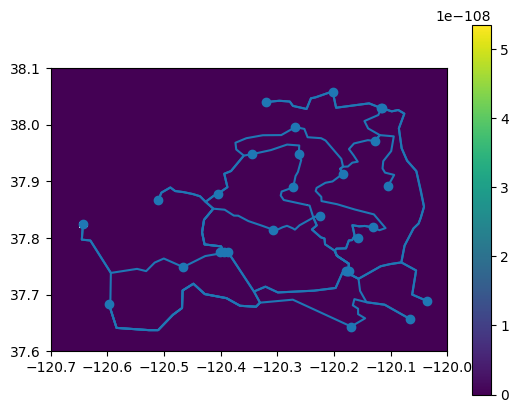

In [58]:
# Plot GeoJSON
fig, ax = plt.subplots(1, 1)
gdf.plot(ax=ax)

# Set the new target coordinates
# target_coords = [-120.35, -120.1, 37.65, 37.85]  # xmin, ymin, xmax, ymax
target_coords = [-120.7, -120, 37.6, 38.1]  # xmin, ymin, xmax, ymax

init_x, init_y = 665, 450

# Set a cell to 100
data[init_y, init_x] = 100

# Create structuring element for dilation
# This will cause dilation to be skewed to the right and downwards
selem = np.array([
    [1, 1, 0],
    [1, 1, 1],
    [0, 0, 0],
])

# Perform dilation
for _ in range(300):
    # Create binary array
    binary = data > 0
    # Dilate binary array
    dilated = binary_dilation(binary, structure=selem)
    # Reduce value at each step by a random value between 0 and 1
    data = data * np.random.rand(*data.shape)
    # Replace the original data with the dilated data, maintaining original values where not dilated
    data = np.where(dilated, data, 0)


# Overlay raster data
img = ax.imshow(data, extent=target_coords)

# Add a colorbar
fig.colorbar(img, ax=ax)

plt.show()

## Create Ignition Points GeoJSON

In [8]:
# Load your CSV file
df = pd.read_csv("scenarios.csv")  # Replace with your CSV file name

# Removing duplicates
df = df.drop_duplicates(subset=['Ignition Point X', 'Ignition Point Y'])

# Create a GeoDataFrame from your DataFrame
geometry = [Point(xy) for xy in zip(df['Ignition Point X'], df['Ignition Point Y'])]
gdf = GeoDataFrame(df, geometry=geometry)

# Convert the GeoDataFrame to a GeoJSON and save to a file
gdf.to_file("output.geojson", driver='GeoJSON')

FileNotFoundError: [Errno 2] No such file or directory: 'scenarios.csv'